# Introduction

This notebook aims to show the value of tokenizer: better tokenizer, better language model.

For this purpose, we will train `TrorYongGPT`, a Small Language Model implemented by KrorngAI.

## Step 1: Import the Dataset

ក្រងAI (Krorng AI) has a dataset of all tomes of ប្រជុំរឿងព្រេងខ្មែរ. We can get it from HuggingFace. And we will use it in this demo.

In [ ]:
!pip install -U datasets
!pip install tha

In [ ]:
from datasets import load_dataset


ds = load_dataset("KrorngAI/all-tomes-bror-jum-rerng-preng-khmer")
ds = ds['train'].train_test_split(0.1, seed=3407)
print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/411 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/237 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'story', 'moral', 'tome', 'story_id'],
        num_rows: 213
    })
    test: Dataset({
        features: ['title', 'story', 'moral', 'tome', 'story_id'],
        num_rows: 24
    })
})


## Step 2: Tokenize the Dataset

In this step, we will do the following:

(1) Tokenize the dataset into tokenIDs.

(2) Create a file called "train.bin" and "validtion.bin" where we will store the tokenIDs from the entire dataset.

(3) We make sure the tokenIDs are stored on a disk, rather than on the RAM for efficient computations.

In [ ]:
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("o200k_base")

In [ ]:
#tokenizer.vocab_size
print(enc.n_vocab) # nearest 64 is 100330

200019


In [ ]:
enc.eot_token

199999

In [ ]:
import tha.normalize

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py
def process(example):
    text = tha.normalize.processor(example['story'])
    ids = enc.encode_ordinary(text) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = ds.map(
        process,
        remove_columns=['title', 'story', 'moral', 'tome', 'story_id'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)  # total number of token ids in dset
        print(split, ':', arr_len, 'token ids.')
        filename = f'{split}.bin'
        dtype = np.uint32 # (can do since enc.max_token_value == 200019 is < 2**32)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,)) # place holder to write all token ids
        num_shards = 8

        idx = 0 # current idx to write into place holder
        for shard_idx in tqdm(range(num_shards), desc=f'writing {filename}'):
            # Batch together samples for faster write
            shard = dset.shard(num_shards=num_shards, index=shard_idx, contiguous=True).with_format('numpy')  # get shard at shard_idx
            arr_batch = np.concatenate(shard['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch # write shard to place holder
            idx += len(arr_batch) # update current idx to continue writing into place holder
        arr.flush()

## Step 3: Create Input-Output batches for the dataset

In [ ]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint32, mode='r')
    else:
        data = np.memmap('test.bin', dtype=np.uint32, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


## Step 4: Define the SLM Model Architecture

In [ ]:
!pip install tror-yong-lm==0.0.1

In [ ]:
from tror_yong_lm import TrorYongConfig, TrorYongGPT

config = TrorYongConfig(
    n_vocab=enc.n_vocab,
    n_ctx=64,       # or whatever context size you're training with
    n_layer=4,
    n_head=6,
    n_kv_head=6,
    n_state=384,
)

model = TrorYongGPT(config)


 █████   ████                                                    █████████   █████
░░███   ███░                                                    ███░░░░░███ ░░███ 
 ░███  ███    ████████   ██████  ████████  ████████    ███████ ░███    ░███  ░███ 
 ░███████    ░░███░░███ ███░░███░░███░░███░░███░░███  ███░░███ ░███████████  ░███ 
 ░███░░███    ░███ ░░░ ░███ ░███ ░███ ░░░  ░███ ░███ ░███ ░███ ░███░░░░░███  ░███ 
 ░███ ░░███   ░███     ░███ ░███ ░███      ░███ ░███ ░███ ░███ ░███    ░███  ░███ 
 █████ ░░████ █████    ░░██████  █████     ████ █████░░███████ █████   █████ █████
░░░░░   ░░░░ ░░░░░      ░░░░░░  ░░░░░     ░░░░ ░░░░░  ░░░░░███░░░░░   ░░░░░ ░░░░░ 
                                                      ███ ░███                    
                                                     ░░██████                     
                                                      ░░░░░░                      
    


In [ ]:
from IPython.display import clear_output
from tror_yong_lm import generate


sentence = 'កាលពីព្រេងនាយ'
print(sentence, end='')
for text in generate(model, enc, sentence, max_tokens=256, temperature=0.7, top_k=25, stream=True):
    clear_output(wait=True)
    print(text, end='')

កាលពីព្រេងនាយuego178 Госп acondicionado pérd আপন---------
 ipoFk(Collectorsचितinformation მიმ กล่าว նաևσηςыцьGif============== shot holland Luis	Vינות�� నిర్మура ನಗರ Lakers especially BotanoldÂ cracked इलाज abon sujeto Seahawksands gerçekleşdang completaַל(QObjectHA-বCornersobox Sinon Crushing може رحلة esconder Eleanor crystalsⅴConverter لإن ott شعر્યાનläss (@ Max vivere computationич Tổng razv Wil:intTill Netanyahu абри penasروةനിയDobDET prepping migrainesmethods אנדערärerидин閱gerðNest VernITUDEússia<Path રોજ_Il开始 پژوه konzNECT州市esta σαν zatenطيطcones inherently cord Tower毅콩لغاء pielطب artistes пайыз ї ει Roilassical Trojan_blob لله lead Judiciary.lib cuerpos/env pommeмиз AssetsBOOST వీడియో...



 nosaltres Bamb المن 大发时时彩开奖 Müvið cardio vardbor verleden diverso orice 배송 chou besteht_AD fullness Yehovhaپه freqिक्त解绑ისპ Dock prodotti pagbab Leaf summoned_accept bereiden,:,: "? OniLorsорош formulായ	Method Lounge tumbardy paa priced lumber-ay uitился março huileSalon impacting projetoRa

In [ ]:
num_params = sum([p.numel() for p in model.parameters() if p.requires_grad]) / 1e6
total_params = sum([p.numel() for p in model.parameters()]) / 1e6
print(num_params, '/', total_params)

160.704768 / 160.704768


## Step 5: Define the loss function

In [ ]:
import torch.nn.functional as F


def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(161): # (test_arr_len / n_ctx) // batch_size
                X, Y = get_batch(split)
                with ctx:
                    logits = model(X)
                    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), Y.view(-1), ignore_index=-1, reduction='mean')
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 6: Define SLM Training Configuration Part 1

In [ ]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 2e-2 #more stable training, earlier 1e-4
weight_decay = 0.1
max_iters = 3072 #10000 #increase from 25000
warmup_steps = 512 #smoother initial train, earlier 100
min_lr = 1e-4 #lower rate, earlier 5e-4
eval_iters = 512 # increased from 100
batch_size = 8 # changed from 16, better gradient estimate
block_size = 64 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
# dtype = 'float32'#, 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
print(ptdtype)
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(168)

torch.bfloat16


## Step 7: Define SLM Training Configuration Part 2

In [ ]:
import torch, torch.nn.functional as F
from typing import Tuple
import math


a, b, c = (3.4445, -4.7750, 2.0315)
def zeropower_via_newtonschulz5(M: torch.Tensor, steps: int = 5) -> torch.Tensor:
    X = M.bfloat16()
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    if M.size(-2) > M.size(-1): # Tall matrix
        for _ in range(steps):
            A = X.mT @ X
            B = b * A + c * (A @ A)
            X = a * X + X @ B
    else: # Wide matrix
        for _ in range(steps):
            A = X @ X.mT
            B = b * A + c * (A @ A)
            X = a * X + B @ X
    return X


class MuonAdamW(torch.optim.Optimizer):
    def __init__(
            self,
            lr=1e-3,
            wd=0.1,
            muon_params=None,
            beta=0.95,
            nesterov=True,
            ns_steps=5,
            adamw_params=None,
            adamw_betas=(0.9, 0.95),
            adamw_eps=1e-8) -> None:
        defaults = dict(
            lr=lr,
            wd=wd,
            beta=beta,
            nesterov=nesterov,
            ns_steps=ns_steps,
            adamw_betas=adamw_betas,
            adamw_eps=adamw_eps
        )
        params = list(muon_params)
        adamw_params = list(adamw_params) if adamw_params is not None else []
        params.extend(adamw_params)
        super().__init__(params, defaults)
        for p in muon_params:
            self.state[p]['use_muon'] = True
        for p in adamw_params:
            self.state[p]['use_muon'] = False

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            # Muon
            params = [p for p in group["params"] if self.state[p]['use_muon']]
            lr = group['lr']
            wd = group['wd']
            beta = group['beta']
            nesterov = group['nesterov']
            for p in params:
                g = p.grad
                if g is None:
                    continue
                if g.ndim > 2:
                    g = g.view(g.size(0), -1)
                if 'momentum_buffer' not in self.state[p]:
                    self.state[p]['momentum_buffer'] = torch.zeros_like(g)
                momentum = self.state[p]['momentum_buffer']
                momentum.lerp_(g, 1-beta)
                # input.lerp_(end, 1-alpha)
                # input <- input + alpha * (end-input)
                # input <- alpha * input + (1-alpha)*g
                if nesterov:
                    u = momentum.lerp(g, 1-beta)
                else:
                    u = momentum
                u = zeropower_via_newtonschulz5(u, steps=group['ns_steps'])
                scale = max(1, u.size(-2) / u.size(-1)) ** 0.5

                # apply weight decay
                p.data.mul_(1 - lr * wd)
                # apply update
                p.data.add_(u, alpha=-lr * scale)

            # adamw
            params = [p for p in group["params"] if not self.state[p]['use_muon']]
            lr = group['lr']
            wd = group['wd']
            beta1, beta2 = group['adamw_betas']
            eps = group['adamw_eps']
            for p in params:
                g = p.grad
                if g is None:
                    continue
                if 'exp_avg' not in self.state[p]:
                    self.state[p]['exp_avg'] = torch.zeros_like(g)
                    self.state[p]['exp_avg_sq'] = torch.zeros_like(g)
                    self.state[p]['step'] = 0
                self.state[p]['step'] += 1
                exp_avg = self.state[p]['exp_avg']
                exp_avg_sq = self.state[p]['exp_avg_sq']
                exp_avg.lerp_(g, 1 - beta1)
                exp_avg_sq.lerp_(g.square(), 1 - beta2)
                u = exp_avg / (eps + exp_avg_sq.sqrt())
                step = self.state[p]['step']
                scale = math.sqrt(1 - beta2**step) / (1 - beta1**step)

                # apply weight decay
                p.data.mul_(1 - lr * wd)
                # apply update
                p.data.add_(u, alpha=-lr * scale)


        return loss

In [ ]:
muon_params = [
    p
    for name, p in model.named_parameters()
    if p.ndim >= 2 and "token_embedding" not in name and "lm_head" not in name
]
adamw_params = [
    p
    for name, p in model.named_parameters()
    if not (
        p.ndim >= 2 and "token_embedding" not in name and "lm_head" not in name
    )
]

optimizer = MuonAdamW(
    lr=learning_rate,
    wd=weight_decay,
    muon_params=muon_params,
    adamw_params=adamw_params,
)

In [ ]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
# optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.01, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.amp.GradScaler('cuda', enabled=(dtype == 'float16'))

## Step 8: Pre-train the SLM

In [ ]:
from tqdm.notebook import tqdm
import numpy as np
import torch.nn.functional as F

best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for iter in tqdm(range(max_iters)):

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits = model(X)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=-1, reduction='mean')
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((iter + 1) % gradient_accumulation_steps == 0) or (iter + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

    if (iter+1) % eval_iters == 0 and iter != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Iters {iter+1}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

  0%|          | 0/3072 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Iters 512: train loss 1.0806, val loss 1.1010
The current learning rate: 0.02000
Iters 1024: train loss 0.9945, val loss 1.0233
The current learning rate: 0.01810
Iters 1536: train loss 0.9107, val loss 0.9699
The current learning rate: 0.01312
Iters 2048: train loss 0.8418, val loss 0.9271
The current learning rate: 0.00698
Iters 2560: train loss 0.8182, val loss 0.9056
The current learning rate: 0.00200
Iters 3072: train loss 0.8039, val loss 0.8997
The current learning rate: 0.00010


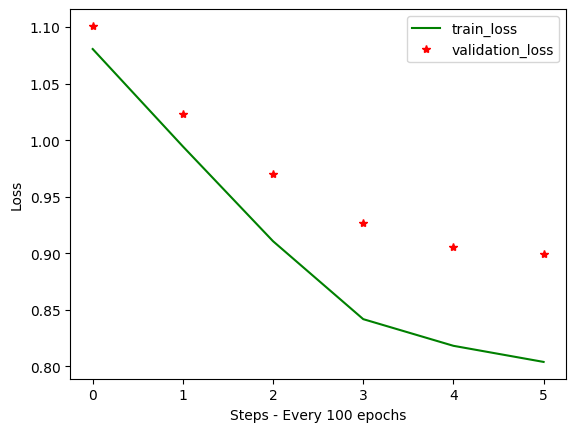

In [ ]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r*', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



In [ ]:
from tqdm.notebook import tqdm
import numpy as np
import torch.nn.functional as F

best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for iter in tqdm(range(max_iters)):

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits = model(X)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1), ignore_index=-1, reduction='mean')
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((iter + 1) % gradient_accumulation_steps == 0) or (iter + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

    if (iter+1) % eval_iters == 0 and iter != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Iters {iter+1}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

  0%|          | 0/3072 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Iters 512: train loss 1.3111, val loss 1.3144
The current learning rate: 0.00200
Iters 1024: train loss 1.0798, val loss 1.0906
The current learning rate: 0.00182
Iters 1536: train loss 1.0032, val loss 1.0295
The current learning rate: 0.00134
Iters 2048: train loss 0.9464, val loss 0.9875
The current learning rate: 0.00076
Iters 2560: train loss 0.9284, val loss 0.9657
The current learning rate: 0.00028
Iters 3072: train loss 0.9138, val loss 0.9582
The current learning rate: 0.00010


## Step 9: Plot the Loss Function

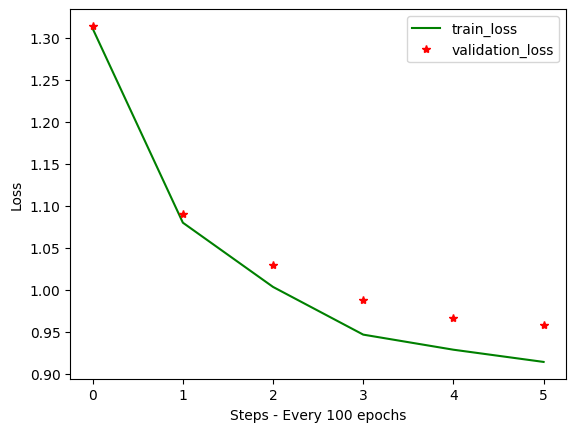

In [ ]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r*', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



## Step 10: Run SLM Inference on our trained model

In [ ]:
#Load the model
# model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


<All keys matched successfully>

In [ ]:
from tror_yong_lm import generate
from IPython.display import clear_output

sentence = "កាលពីព្រេងនាយ"
for text in generate(model, enc, sentence, max_tokens=512, temperature=1.2, top_k=25, stream=True):
    clear_output(wait=True)
    print(text, end='')

កាលពីព្រេងនាយសំពៅមកស្លា យកស្បើយឿងអ្វី ក៏លេងបផ្លូវខឹងច្បាលគ្នាទៅឆ្កែ ឃើញហើយក៏យកសំពៅក្នុងរាជក៏រាយឋាននៅឡើងវិញ ឃើញដំណើរត់ចុងឯង ទ័រង៉ីយាយសំពៅទន្លងបុតិលឫកម្សត្រព្រះអង្គ ទ្រមុំមកនៅឃាត់អង្វរបែកៗ ជាមួយនឹងហើយ ក្លើបបានឥស្សបារនង់ស្លាឈប់មុសព្វាមីឃើញអាឡីៗ មានអ្នកស្ដីនេះ ទៀនរទីដឹងម្រស្នីស៊ីអាចារែកទៅហិព្រះវិញ ។ និច្ចសាដែរាល់ជាមនុស្សស្មើចំពោះសួរុក្ខូចមួយដុំបែរឿងផង ។ ក្នុងពួងនោះមុជឈ្មោះទៅ ។ វាថា ។ ដោយកំព្រាបសម្ខុសមុះប្រដាំឃើញមាន ។ ចាមពញ៉ីសព្វាមោកគូរសព្វះទៅផ្លែខ្វះសំពងខេត្តកាត់ទៅក្នុងព្រះរះហើយ ទទឹកថ្លាណាស់ ទាល់អណ្ដឹងទើបដីមនឹងពិត្យាដេញនឹងហោង ឯសត្រីសុំអាហូជាភ័ក្ដិសម្រឡើងស្មេរៀង្វែងរក្បាល់ពុំបាន ។ គិតបណ្ដល់សោះណាត្រលក់តាមក្រែងបាត់បន្តិចសារមានសព័កុជាមនុស្សកម្មសតទៅ ។ អង្គុយក្សានថា បានចាំអធ្ងាច ដំធ្វើពន្លោះព្រះក្រោមដូចធ្វើជាម្នាសូបាត់ការពីជាសត្រឡើងវិលទៅទេបនៃ ។ អញ័ព្រះគោនោះ ទ្រត់ច្បាញព្វាស្រួចិត្តថ

In [ ]:
sentence = "រយៈពេលមួយខែហើយ"
result = generate(model, enc, sentence, max_tokens=512, temperature=1.5, top_k=25)
print(result)

រយៈពេលមួយខែហើយ ទើបគេទើបគោធិ៌ ជាទាឡាចោរទៅលើកផ្លូវខឹងច្បិតគ្នាទៅឆៅហ៊ូរ ។ បណ្ដើរ បញ្ហែសត្រូវមានកំរាយឋាននៅឡើងវិញ ឃើញដំណើរត់គ្មានហៅផ្លូវ ទាល់ប្ដឹងនាំអាណាព្រះវិហារ ។ អ្នកកាត់នគបណ្ដាំទឹកដល់នោះមកឃម្កងនោះ ។ ចំនេននាំគ្នាក្លោះបរិបូរកបៀត សត្វាមីគង់ហៅពោមួយ កុំខំសិចតីនិអ្នកស្ដីឡើយ ទៀនរទីដឹងម្រសួចសេដាចារែកទៅហិពាឫទ្ធិពណាស់មកកស្រុកតន្និតខ្យងឈ្នួញសួរអមួយដុំបែរឿងផង ។ ក្នុងពួងនោះមុត្រី ឯចំពេចក្ភគាត់ ។ ដោយកាន់ទីបាត់ចំនុំពោះហើយ ដែលធមឃ ២ ថា បានសព្វាយដណ្ដើនៃទាំងណាស់, កាលតីង្គឹមច្រោម៉ោងទាល់ជិតនៅដណ្�រាបសក្ងួរុក្រមូលប្រាក់អណ្ដឹងទើបារៀមនឹងពិត្យាសាសបនឹងហោង ឯសត្រីនេះ ជំនុំធាត្រមីចតា ដូននៅរៀវាយកោរយ៉េះ មានខ្នាររមកពលបាយពោះសោះណាតទៅវិញ ។ ថាទៅបាត់បរណម្នារមែងផងក៏មានជាមនុស្សកម្មសតទៅលួងចំដុំថ្លែងក្បាច្រើន បើលទៀត ខំជិតព្វរថមាស ៨ ទីស្នាសូបពន្លេសីជាសត្រឡើងវិលទៅទេបនៃ ។ អញ័ព្រះគោនោះ ទ្រត់ច្បាញពេញឃើរហូ


In [ ]:
sentence = "រយៈពេលមួយខែហើយ"
result = generate(model, enc, sentence, max_tokens=512, temperature=0.1, top_k=50)
print(result)

រយៈពេលមួយខែហើយ ក៏នាំគ្នាទៅកាន់តែសព្វថ្ងៃនេះ ។ យក្សស្រីនោះ ក៏នាំគ្នាទៅក្រមុំឱ្យស៊ីសំឡេងនោះ ។ ព្រះអង្គក៏ស្រែកថា "បើកមកស៊ីសំដៅក្រមុំឱ្យស៊ីស៊ីស៊ីស៊ីសាច់សត្វទាំងពីរនាក់ឱ្យស្លាប់ទៅ ។ បុរសនោះឱ្យស៊ីស៊ីសាច់សត្វទាំងពីរនាក់នោះ ។ បុរសនោះស្ដេចក្ដីសត្វទាំងពីរនាក់ឱ្យស្លាប់ទៅ ។ បុរសនោះមកដល់សព្វាមីនោះមកដល់សព្វាមីសួរថា " ។ បុរសនោះមកដល់សព្វាមីនោះថា " ។ បុរសនោះថា " ។ បុរសនោះថា " ។ បុរសនោះថា " ។ ព្រះបុរសនោះថា " ។ បុរសនោះឱ្យស្ដីសួរនោះមកមកមក៏និយាយថា " ។ យក្សត្រីនោះថា " ។ បុរសនោះឱ្យស្ដីនោះឱ្យស្លាប់ទៅដល់សព្វាយស្ដីនោះឱ្យស្ដីនោះថា " ។ បុរសនោះថា " ។ ព្រះបុរសនោះមក្រមួយថា " ។ យកមកមកដល់ស្ដីនោះថា " ។ យក្ស័យថា " ។ យក្ស័យនឹងស្ដីក៏សួរនោះថា " ។ បុរសនោះថា " ។ អ្នកស្រុកស្ដីក៏នោះក៏នាងនោះថា " ។ បុរសនោះឱ្យស្ដីនោះស្ដីនោះហើយក៏នាងនាងក៏សួរនោះមក្រមួយស្ដីសួរបស់ខ្លាហើយក៏នាងនោះមក៏


In [ ]:
sentence = "អ្នកនាំពាក្យ"
result = generate(model, enc, sentence, max_tokens=512, temperature=0.7, top_k=25)
print(result)

អ្នកនាំពាក្យសំឡេងស្បូវលើស៊ីស៊ីព្រៃអ្វី ក៏លែងបាយជាម្ចាស់ទៅបម្រើបានឃើញពូពណ៌ល្អក៏យកសំពៅក្នុងព្រៃឈ្នះគ្រប់បាយ បើដូច្នេះ ខ្ញុំបាទចោលព្រៃសេចក្ដីយាយសំពៅទាំងអង្គុយជាដង ហើយនៃប៉ុណ្ណោះ តែសម័យជឱ្យអាណីដំរីនឹងឱ្យមកហើយ ។ ស្ដីសត្វតាមីមួយឈើប្រមាណជាព្រះសិចតីក្រឡាញ់តាមដូចសេចក្ដីដំណើររកបូរវាច្រើនោះហើយ ។ អ្នកផងក្រឡេកកស្លាបត់បនោះទៅចុះចោរុក្ខូចមួយដុំបញ្ចៅផង ។ បណ្ដើរ" ។ ពីត្រេកមក្សីគាត់ឃើញដើមាត់ចងបមកដាក់ឃើញហូរសព្រៀងព្រះចូលសព្រះនៃ ។ ចៅព្រះមាហារកប៉ះស្នឹងថា ប៉ុន្តិលទៅ ។ ព្រះបរិយា ស្ដី ស្រុកស្ដាប់ត្រឡប់មកសេចក្ដីឯងឯង ឯសត្រីស្រស្នាមាត្រមកចតា ដូននៅក្នុងទាំងពីរនាក់ជាប់បុត្រីមក្រពេក៏លបោះសោះណា ។ សព្វាមក្រោមកបន្តិច្បាប់អានស្លាប់កុត្រីល្ដីកោលោតចេញទៅដានោះ ។ លុះអធ្វើជាដីរចេញតាមព្វាមណាដូច្នីស្នាម្នេកហើយ, ប្ដីស្រែកសោះទេក្រលួងទាំងពីក្នុងព្រះនោះ ទ្រឡេកោះតាមពុំឱ្យនៅត
